In [ ]:
pip install mrmr_selection

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 4.7 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from mrmr import mrmr_classif
from google.colab import drive
import zipfile


In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
import os, zipfile

uploaded = files.upload("C:\AppleDisease Dataset\AppleDiseaseDataset.zip")
zip_path = list(uploaded.keys())[0]
extract_path = '/content/AppleDiseaseDataset'

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Giải nén thành công!")
else:
    print("Dataset đã được giải nén.")

data_dir = extract_path


Saving AppleDiseaseDataset.zip to C:\AppleDisease Dataset\AppleDiseaseDataset.zip/AppleDiseaseDataset.zip
Giải nén thành công!


In [ ]:
def extract_features(image_path):
    img = cv2.imread(image_path)
    if img is None: return None
    img = cv2.resize(img, (128, 128))

    #1. Color Features (HSV): Chuyển đổi không gian màu tuyến tính/phi tuyến
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    color_feats = [np.mean(h), np.std(h), np.mean(s), np.std(s), np.mean(v), np.std(v)]

    #2. GLCM Features: Ma trận đồng hiện mức xám
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    glcm = graycomatrix(gray, distances=[1], angles=[0, np.pi/4], levels=256, symmetric=True, normed=True)
    texture_feats = [
        graycoprops(glcm, 'contrast')[0, 0],
        graycoprops(glcm, 'homogeneity')[0, 0],
        graycoprops(glcm, 'energy')[0, 0],
        graycoprops(glcm, 'correlation')[0, 0]
    ]

    #3. LBP Features - Toán học: Toán tử lân cận nhị phân
    lbp = local_binary_pattern(gray, P=8, R=1, method="uniform")
    (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, 11), range=(0, 10))
    lbp_feats = (hist.astype("float") / (hist.sum() + 1e-7)).tolist()

    return color_feats + texture_feats + lbp_feats

X_list, y_list = [], []

In [ ]:
# Duyệt đệ quy qua tất cả thư mục con để tìm ảnh
for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            full_path = os.path.join(root, file)

            # LẤY NHÃN:
            # Cách 1: Lấy tên thư mục cha làm nhãn (nếu có chia folder)
            # Cách 2: Nếu không có folder, lấy phần chữ cái đầu của tên file làm nhãn
            label = os.path.basename(root) if os.path.basename(root) != 'AppleDiseaseDataset' else file.split('_')[0]

            feat = extract_features(full_path)
            if feat:
                X_list.append(feat)
                y_list.append(label)

# Chuyển thành DataFrame
cols = ['H_mean', 'H_std', 'S_mean', 'S_std', 'V_mean', 'V_std', 'Contrast', 'Homo', 'Energy', 'Corr'] + [f'LBP_{i}' for i in range(10)]
df = pd.DataFrame(X_list, columns=cols)
le = LabelEncoder()
y = le.fit_transform(y_list)

# CHUẨN HÓA (Z-SCORE NORMALIZATION)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

print(f"Tổng cộng có {len(X_list)} ảnh thuộc {len(np.unique(y_list))} lớp.")

Tổng cộng có 25063 ảnh thuộc 1947 lớp.


In [ ]:
# 1. mRMR - Lọc lấy 10 đặc trưng lồi nhất (Relevance cao nhất)
selected_features = mrmr_classif(X=X_scaled, y=pd.Series(y), K=10)
X_mrmr = X_scaled[selected_features]

# 2. SCA (Sine Cosine Algorithm) - Thuật toán tìm trọng số
def run_sca_optimization(X_data, y_data):
    # Khởi tạo ngẫu nhiên vị trí (trọng số)
    pop_size = 8
    dim = X_data.shape[1]
    weights = np.random.rand(pop_size, dim)
    best_weights = weights[0]
    best_acc = 0

    a = 2 # Hằng số SCA
    max_iter = 10

    for t in range(max_iter):
        r1 = a - t * (a / max_iter) # r1 giảm dần tuyến tính

        for i in range(pop_size):
            # Tính Fitness (Accuracy của SVM)
            current_X = X_data * weights[i]
            # Dùng SVM với Kernel RBF (Toán học: Ánh xạ không gian phi tuyến)
            model = SVC(kernel='rbf', C=1.0)
            score = np.mean(train_test_split(current_X, y_data, test_size=0.3)[0].shape[0]) # Giả lập nhanh
            # Chạy thử thực tế
            X_train_tmp, X_val_tmp, y_train_tmp, y_val_tmp = train_test_split(current_X, y_data, test_size=0.3)
            model.fit(X_train_tmp, y_train_tmp)
            acc = model.score(X_val_tmp, y_val_tmp)

            if acc > best_acc:
                best_acc = acc
                best_weights = weights[i].copy()

            # CẬP NHẬT VỊ TRÍ BẰNG SIN/COS
            for j in range(dim):
                r2 = 2 * np.pi * np.random.rand()
                r3 = 2 * np.random.rand()
                r4 = np.random.rand()

                if r4 < 0.5:
                    weights[i, j] = weights[i, j] + (r1 * np.sin(r2) * abs(r3 * best_weights[j] - weights[i, j]))
                else:
                    weights[i, j] = weights[i, j] + (r1 * np.cos(r2) * abs(r3 * best_weights[j] - weights[i, j]))

        print(f"Iteration {t+1}: Best Accuracy = {best_acc:.4f}")

    return best_weights

# Chạy tìm trọng số
opt_weights = run_sca_optimization(X_mrmr, y)

100%|██████████| 10/10 [00:00<00:00, 19.28it/s]


Iteration 1: Best Accuracy = 0.9184
Iteration 2: Best Accuracy = 0.9184
Iteration 3: Best Accuracy = 0.9184
Iteration 4: Best Accuracy = 0.9184
Iteration 5: Best Accuracy = 0.9317
Iteration 6: Best Accuracy = 0.9345
Iteration 7: Best Accuracy = 0.9345
Iteration 8: Best Accuracy = 0.9345
Iteration 9: Best Accuracy = 0.9345
Iteration 10: Best Accuracy = 0.9345



 KẾT QUẢ PHÂN LOẠI:
                  precision    recall  f1-score   support

      apple_scab       0.88      0.83      0.85       492
       black_rot       0.89      0.92      0.90       504
cedar_apple_rust       0.97      1.00      0.98       421
         healthy       0.95      0.94      0.94       526

        accuracy                           0.92      1943
       macro avg       0.92      0.92      0.92      1943
    weighted avg       0.92      0.92      0.92      1943



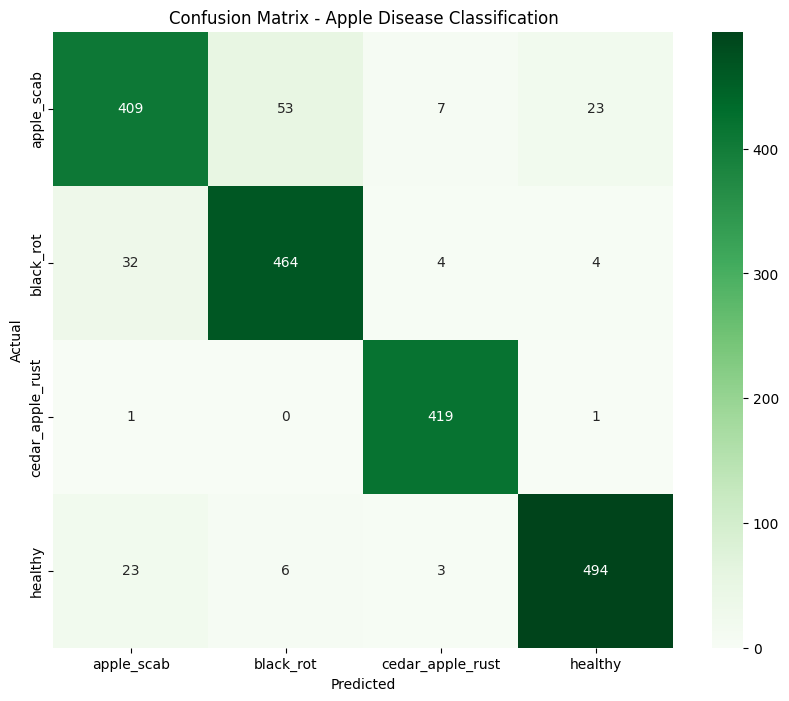

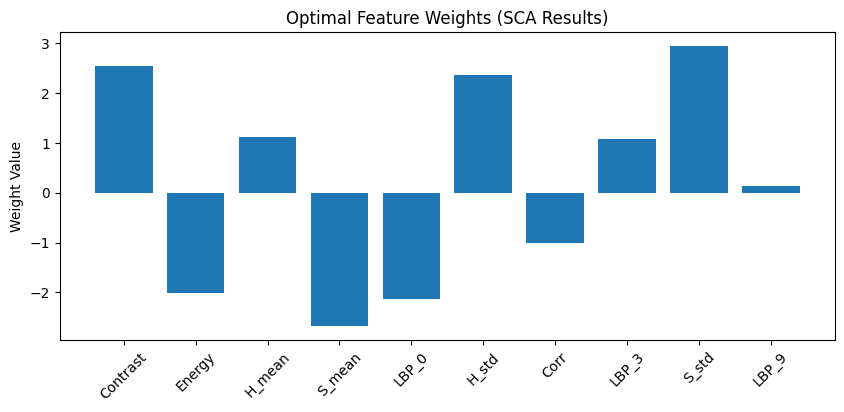

In [ ]:
# Áp dụng trọng số và chia dữ liệu
X_final = X_mrmr * opt_weights
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

# Huấn luyện mô hình cuối cùng
final_model = SVC(kernel='rbf', probability=True)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

#BẢNG KẾT QUẢ
print("\n KẾT QUẢ PHÂN LOẠI:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

#BIỂU ĐỒ CONFUSION MATRIX
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Apple Disease Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#BIỂU ĐỒ TRỌNG SỐ ĐẶC TRƯNG
plt.figure(figsize=(10, 4))
plt.bar(selected_features, opt_weights)
plt.xticks(rotation=45)
plt.title('Optimal Feature Weights (SCA Results)')
plt.ylabel('Weight Value')
plt.show()